In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from fcmeans import FCM
import sys
import os

# Assicuriamoci che le metriche siano importate
# Se le hai nel file src/utils/metrics.py usa:
sys.path.append(os.path.abspath('..'))
from src.utils.metrics import xie_beni_index, calculate_silhouette

def run_analysis_and_reconstruction(image_path, n_clusters=3):
    """
    Esegue l'intera pipeline di analisi:
    1. Clustering (FCM vs KMeans)
    2. Calcolo Metriche (Xie-Beni, Silhouette)
    3. Visualizzazione (Ricostruzione Soft vs Hard)
    """
    
    # 1. CARICAMENTO
    print(f"--- Analisi Completa: {os.path.basename(image_path)} ---")
    img_original = np.load(image_path)
    H, W = img_original.shape
    X = img_original.reshape(-1, 1)

    # ---------------------------------------------------------
    # 2. FUZZY C-MEANS
    # ---------------------------------------------------------
    print("1. Esecuzione Fuzzy C-Means...")
    fcm = FCM(n_clusters=n_clusters, m=2.0)
    fcm.fit(X)
    
    # Dati per metriche
    U_fcm = fcm.u
    centers_fcm = fcm.centers
    labels_fcm = fcm.predict(X) # Serve per la Silhouette
    
    # Ricostruzione Soft (La tua preferita)
    X_fcm_soft = U_fcm @ centers_fcm
    img_fcm_soft = X_fcm_soft.reshape(H, W)

    # ---------------------------------------------------------
    # 3. K-MEANS (HARD)
    # ---------------------------------------------------------
    print("2. Esecuzione K-Means...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    kmeans.fit(X)
    
    # Dati per metriche
    labels_kmeans = kmeans.labels_
    centers_kmeans = kmeans.cluster_centers_
    
    # Creiamo una U 'dummy' (0 o 1) per calcolare Xie-Beni sul K-Means
    U_kmeans = np.zeros((X.shape[0], n_clusters))
    U_kmeans[np.arange(X.shape[0]), labels_kmeans] = 1
    
    # Ricostruzione Hard (Posterizzata)
    X_kmeans_hard = centers_kmeans[labels_kmeans]
    img_kmeans_hard = X_kmeans_hard.reshape(H, W)

    # ---------------------------------------------------------
    # 4. CALCOLO E STAMPA METRICHE
    # ---------------------------------------------------------
    print("\n--- RISULTATI METRICHE ---")
    
    # Xie-Beni (Minore è meglio)
    xb_fcm = xie_beni_index(X, U_fcm, centers_fcm)
    xb_kmeans = xie_beni_index(X, U_kmeans, centers_kmeans)
    
    # Silhouette (Maggiore è meglio)
    sil_fcm = calculate_silhouette(X, labels_fcm)
    sil_kmeans = calculate_silhouette(X, labels_kmeans)
    
    print(f"Xie-Beni Index (Lower is Better):")
    print(f"  FCM:     {xb_fcm:.5f} {'(WIN)' if xb_fcm < xb_kmeans else ''}")
    print(f"  K-Means: {xb_kmeans:.5f} {'(WIN)' if xb_kmeans < xb_fcm else ''}")
    
    print(f"Silhouette Score (Higher is Better):")
    print(f"  FCM:     {sil_fcm:.5f}")
    print(f"  K-Means: {sil_kmeans:.5f}")

    # ---------------------------------------------------------
    # 5. VISUALIZZAZIONE
    # ---------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Immagine FCM (Soft)
    axes[0].imshow(img_fcm_soft, cmap='gray')
    axes[0].set_title(f"FCM Soft Reconstruction\nXB Index: {xb_fcm:.3f}", fontsize=14)
    axes[0].axis('off')
    
    # Immagine Originale
    axes[1].imshow(img_original, cmap='gray')
    axes[1].set_title("Immagine Originale", fontsize=14)
    axes[1].axis('off')
    
    # Immagine K-Means (Hard)
    axes[2].imshow(img_kmeans_hard, cmap='gray')
    axes[2].set_title(f"K-Means Hard Reconstruction\nXB Index: {xb_kmeans:.3f}", fontsize=14)
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

    # Restituiamo i dati utili per eventuali grafici successivi (Membership Maps)
    return U_fcm, centers_fcm, U_kmeans

--- Analisi Completa: Normal (11).npy ---
1. Esecuzione Fuzzy C-Means...
2. Esecuzione K-Means...

--- RISULTATI METRICHE ---
Xie-Beni Index (Lower is Better):
  FCM:     0.14191 (WIN)
  K-Means: 0.18620 
Silhouette Score (Higher is Better):
  FCM:     0.58790
  K-Means: 0.58726


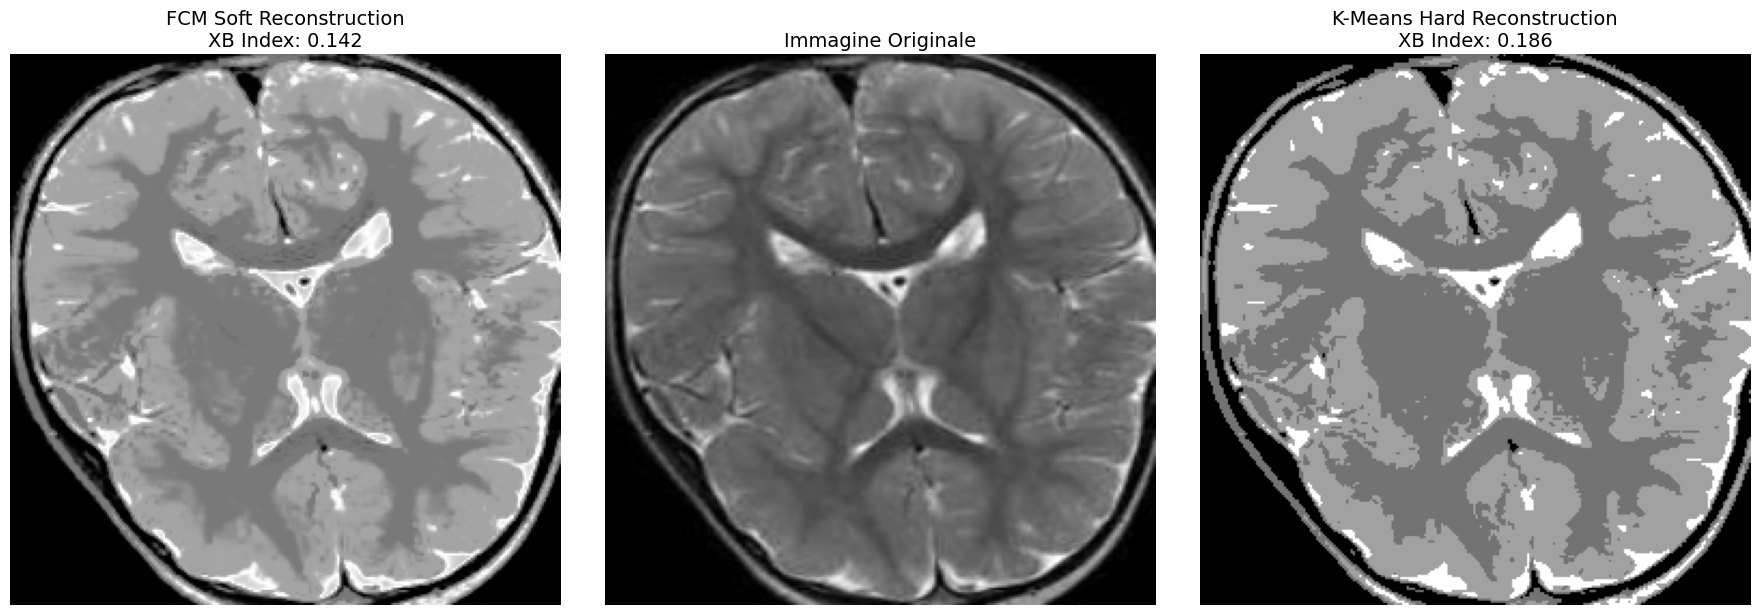

In [30]:
percorso_immagine = "../data/processed/Normal (11).npy"

matrice_fcm, centri_fcm, U_kmeans = run_analysis_and_reconstruction(
    image_path=percorso_immagine, 
    n_clusters=4
)

Valori dei Centri dei Cluster: 0(nero) - 255(bianco)

Centro Cluster 1: 6.3123
Centro Cluster 2: 162.6616
Centro Cluster 3: 80.2495
Centro Cluster 4: 107.3591
--- Visualizzazione Membership Maps: Fuzzy C-Means (FCM) ---


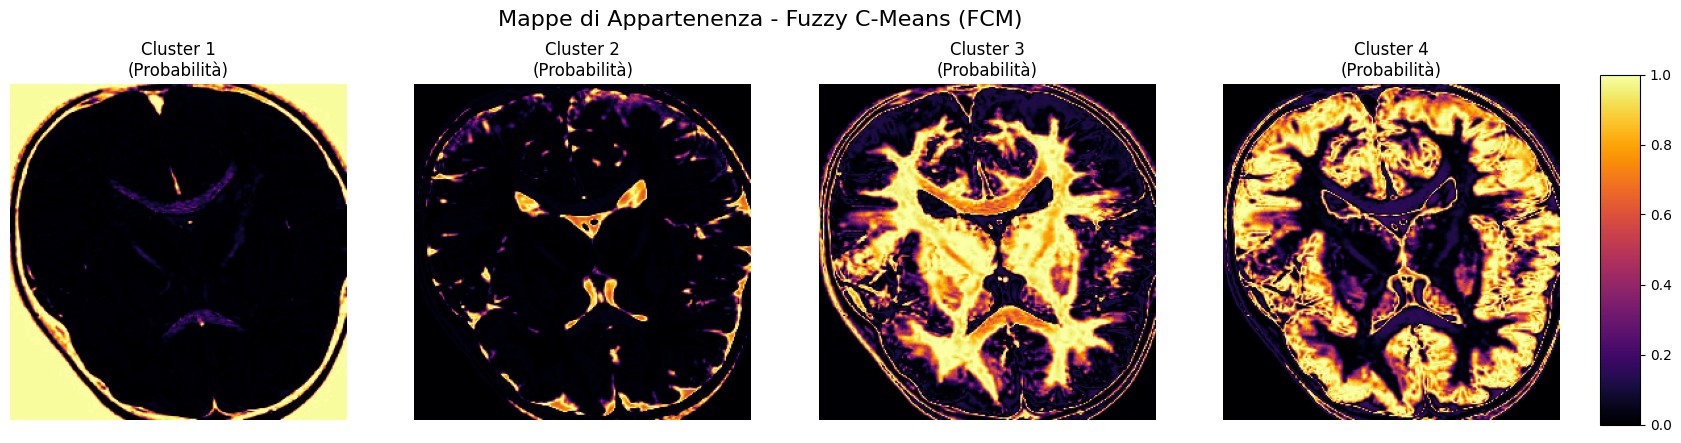

--- Visualizzazione Membership Maps: Hard C-Means ---


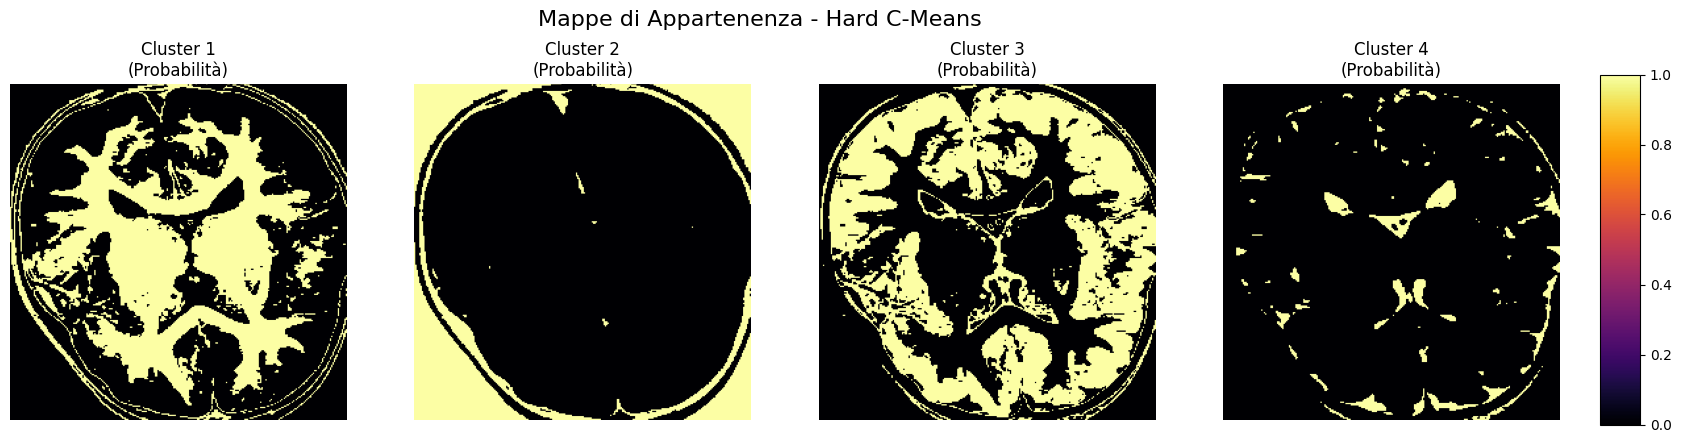

In [31]:
from src.utils.visualizer import visualize_membership_maps

temp_img = np.load(percorso_immagine) 
shape_img = temp_img.shape 

print("Valori dei Centri dei Cluster: 0(nero) - 255(bianco)\n")
for i in range(centri_fcm.shape[0]):
    print(f"Centro Cluster {i+1}: {255*centri_fcm[i][0]:.4f}")

visualize_membership_maps(matrice_fcm, shape_img, algorithm_name="Fuzzy C-Means (FCM)", cmap='inferno')
visualize_membership_maps(U_kmeans, shape_img, algorithm_name="Hard C-Means", cmap='inferno')
